In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from linearmodels import PanelOLS, RandomEffects
import matplotlib.pyplot as plt
import japanize_matplotlib
import seaborn as sns
from stargazer.stargazer import Stargazer
from scipy.stats import norm
from scipy.stats import chi2
import os

pd.options.display.float_format = '{:.2f}'.format

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from linearmodels.iv import IV2SLS

from econml.dml import LinearDML

**discountのCATE**


median_playtime_forever
炎上の影響を高評価率によって引きたい

CCUではなく、他の妥当な比説明変数を使いたいが、量（Review）と質（プレイ時間中央値）の両方の関係も見たい

それらを踏まえた上で割引のCATEを測りたい

なんか教科書で習ったHeckmanと違いあるなって思ってたけど、そもそも使われ方が変わってきたのね。よく言われる賃金の例で言えば、失業者データ(賃金＝0)のデータが大量に取得できるようになって、かつその中で構造的失業者と摩擦的失業を分けるようなもんか
冷静にこのデータセットの割引率って、データを取得した時点？じゃあ介入効果なのかわからないし、どういうふうにデータ取ったんだろ？

ていうかそもそも、割引なんて複数回行われることが前提だし、データセットはパネルじゃないと絶対に意思決定に役立つ効果は測れないやん。じゃあ動的政策評価に基づくモデルが必要になるやん。でも技術ないし今は無理だな、スクレイピングさせて1日一回データセットを更新させ続けるAIエージェントでも作ろうかな。流石に学部論文ではできる気しないから修士論文かなそれは
てか、もとの値段に対してどれくらい引かれたのか(でも割引そのものの効果なので、CATEを前提に置いていたらいいんじゃないの？)とか、そもそもの製造元のブランドとか(まあこれは時系列データにして固定効果でさっぴくとかしなきゃ無理か)、全然まだまだやるべきことがあるな

In [ ]:
path = kagglehub.dataset_download("artermiloff/steam-games-dataset")

print("Path:", path)

csv_path = os.path.join(path, "games_march2025_cleaned.csv")

df = pd.read_csv(csv_path, index_col=False, quotechar='"')
df = df.drop(columns=['score_rank'])

pd.set_option('display.max_columns', None)

# pd.reset_option('display.max_columns')

df.head()

,appid,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,header_image,website,support_url,support_email,windows,mac,linux,metacritic_score,metacritic_url,achievements,recommendations,notes,supported_languages,full_audio_languages,packages,developers,publishers,categories,genres,screenshots,movies,user_score,positive,negative,estimated_owners,average_playtime_forever,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent
0,730,Counter-Strike 2,2012-08-21,0,0.00,1,"For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...",NaN,https://shared.akamai.steamstatic.com/store_it...,http://counter-strike.net/,NaN,NaN,True,False,True,0,NaN,1,4401572,Includes intense violence and blood.,"['Czech', 'Danish', 'Dutch', 'English', 'Finni...","['English', 'Indonesian']","[{'title': 'Buy Counter-Strike 2', 'descriptio...",['Valve'],['Valve'],"['Multi-player', 'Cross-Platform Multiplayer',...","['Action', 'Free To Play']",['https://shared.akamai.steamstatic.com/store_...,['http://video.akamai.steamstatic.com/store_tr...,0,7480813,1135108,100000000 - 200000000,33189,879,5174,350,0,1212356,"{'FPS': 90857, 'Shooter': 65397, 'Multiplayer'...",86,8632939,82,96473
1,578080,PUBG: BATTLEGROUNDS,2017-12-21,0,0.00,0,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...","LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",Play PUBG: BATTLEGROUNDS for free. Land on str...,NaN,https://shared.akamai.steamstatic.com/store_it...,https://www.pubg.com,https://support.pubg.com/hc/en-us,NaN,True,False,False,0,NaN,37,1732007,NaN,"['English', 'Korean', 'Simplified Chinese', 'F...",[],[],['PUBG Corporation'],"['KRAFTON, Inc.']","['Multi-player', 'PvP', 'Online PvP', 'Stats',...","['Action', 'Adventure', 'Massively Multiplayer...",['https://shared.akamai.steamstatic.com/store_...,[],0,1487960,1024436,50000000 - 100000000,0,0,0,0,0,616738,"{'Survival': 14838, 'Shooter': 12727, 'Battle ...",59,2513842,68,16720
2,570,Dota 2,2013-07-09,0,0.00,2,"The most-played game on Steam. Every day, mill...","The most-played game on Steam. Every day, mill...","Every day, millions of players worldwide enter...",“A modern multiplayer masterpiece.” 9.5/10 – D...,https://shared.akamai.steamstatic.com/store_it...,http://www.dota2.com/,NaN,NaN,True,True,True,90,https://www.metacritic.com/game/pc/dota-2?ftag...,0,14337,"Dota 2 includes fantasy violence, use of alcoh...","['Bulgarian', 'Czech', 'Danish', 'Dutch', 'Eng...","['English', 'Korean', 'Simplified Chinese', 'V...","[{'title': 'Buy Dota 2', 'description': '', 's...",['Valve'],['Valve'],"['Multi-player', 'Co-op', 'Steam Trading Cards...","['Action', 'Strategy', 'Free To Play']",['https://shared.akamai.steamstatic.com/store_...,['http://video.akamai.steamstatic.com/store_tr...,0,1998462,451338,200000000 - 500000000,43031,1536,898,892,0,555977,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81,2452595,80,29366
3,271590,Grand Theft Auto V Legacy,2015-04-13,17,0.00,0,"When a young street hustler, a retired bank ro...","When a young street hustler, a retired bank ro...",Grand Theft Auto V for PC offers players the o...,NaN,https://shared.akamai.steamstatic.com/store_it...,https://www.rockstargames.com/V/,https://support.rockstargames.com,NaN,True,False,False,96,https://www.metacritic.com/game/pc/grand-theft...,77,1803063,NaN,"['English', 'French', 'Italian', 'German', 'Sp...","['English', 'Spanish - Latin America']","[{'title': 'Buy Shark Cash Cards', 'descriptio...",['Rockstar North'],['Rockstar Games'],"['Single-player', 'Multi-player', 'PvP', 'Onli...","['Action', 'Adventure']",['https://shared.akamai.steamstatic.com/store_...,['http://video.akamai.steamstatic.com/store_tr...,0,1719950,250012,50000000 - 100000000,19323,771,7101,74,0,117698,"{'Open World': 32644, 'Action': 23539, 'M

In [5]:
df.sample(n=10)

,appid,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,header_image,website,support_url,support_email,windows,mac,linux,metacritic_score,metacritic_url,achievements,recommendations,notes,supported_languages,full_audio_languages,packages,developers,publishers,categories,genres,screenshots,movies,user_score,positive,negative,estimated_owners,average_playtime_forever,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent,is_active,is_early_access,language_count,log_reviews,imr
75557,991680,炎之陨落 The Fallen of The Blaze Empire,2019-04-26,0,2.99,0,Version information The current version is the...,Version information The current version is the...,The Fall of The Blaze Empire is an indie game ...,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,NaN,warthogstudio@qq.com,1.00,0.00,0.00,0,NaN,0,0,NaN,['Simplified Chinese'],[],[{'title': 'Buy 炎之陨落 The Fallen of The Blaze E...,['Warthog Studio'],['Warthog Studio'],"['Single-player', 'Family Sharing']","['Adventure', 'Casual', 'Indie', 'RPG', 'Early...",['https://shared.akamai.steamstatic.com/store_...,['http://video.akamai.steamstatic.com/store_tr...,0,9,7,0 - 20000,0,0,0,0,0,0,"{'RPG': 41, 'Early Access': 32, 'Adventure': 3...",-1,-1,-1,-1,0,1.00,1.00,-inf,0.83
83604,1648450,Card Tower Defence,2021-06-27,0,2.99,0,I recommend it to these people. Anyone who kno...,I recommend it to these people. Anyone who kno...,A game that the developer has cleared once wit...,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,https://cafe.naver.com/eastvillgame,eastvillage@eastvill.com,1.00,1.00,0.00,0,NaN,36,0,NaN,"['English', 'Japanese', 'Korean']",[],"[{'title': 'Buy Card Tower Defence', 'descript...",['EastVillage'],['Eastvillage'],"['Single-player', 'Steam Achievements', 'Famil...","['Casual', 'Indie']",['https://shared.akamai.steamstatic.com/store_...,['http://video.akamai.steamstatic.com/store_tr...,0,3,3,0 - 20000,0,0,0,0,0,0,"{'Tower Defense': 53, 'Board Game': 45, 'Choic...",-1,-1,-1,-1,0,0.00,3.00,-inf,0.49
81756,911640,ChromaSquares,2018-09-14,0,4.99,0,ChromaSquares is a puzzle game where the goal ...,ChromaSquares is a puzzle game where the goal ...,A game of strategy complicated by chance.,NaN,https://shared.akamai.steamstatic.com/store_it...,https://racingthought.com/chromasquares/,https://racingthought.com/contact/,support@racingthought.com,1.00,1.00,1.00,0,NaN,20,0,NaN,"['English', 'German']",[],"[{'title': 'Buy ChromaSquares', 'description':...",['Racing Thought Studios'],['Racing Thought Studios'],"['Single-player', 'Steam Achievements', 'Famil...","['Casual', 'Indie', 'Strategy']",['https://shared.akamai.steamstatic.com/store_...,['http://video.akamai.steamstatic.com/store_tr...,0,1,0,0 - 20000,0,0,0,0,0,0,"{'Strategy': 31, 'Indie': 31, 'Casual': 31, 'P...",-1,-1,-1,-1,0,0.00,2.00,-inf,0.43
12683,1188970,Ether Loop,2020-01-21,0,11.99,1,Ether Loop is a hardcore fast-paced bullet hel...,Ether Loop is a hardcore fast-paced bullet hel...,Ether Loop is a hardcore fast-paced bullet hel...,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,NaN,moonlens.studio@gmail.com,1.00,0.00,0.00,0,NaN,12,263,NaN,"['English', 'Japanese', 'Simplified Chinese', ...","['English', 'Japanese', 'Simplified Chinese', ...","[{'title': 'Buy Ether Loop', 'description': ''...",['Moon Lens'],"['Moon Lens', 'Pleasant Rain Ltd']","['Single-player', 'Steam Achievements', 'Parti...","['Action', 'Adventure', 'Indie']",['https://shared.akamai.steamstatic.com/store_...,['http://video.akamai.steamstatic.com/store_tr...,0,224,93,50000 - 100000,0,0,0,0,0,0,"{'Action': 42, 'Indie': 42, 'Adventure': 40, '...",68,263,-1,-1,1,0.00,6.00,5.58,0.69
23190,3277480,One Night ~Young Bride for One Night~,2024-11-01,0,15.99,0,This game's theme is 'a situational trial'! Po...,This game's theme is 'a situational trial'! Po...,"Finally, my reunion with my 

除外制約の妥当性の確認が必要
language_count が本当に「参入には影響するがレビュー数（のdiscountへの感応度）には直接影響しない」といえるかは、理論的に正当化する必要があります。
IMRの線形加算という仮定
WにIMRを加えるだけでは、選択方程式とアウトカム方程式の誤差項の分布に関する仮定が必要です。
LinearDMLの「Linear」の意味
CATEがXの線形関数であると仮定しています（τ(X) = X・β）。非線形な効果修飾が疑われる場合はCausalForestDMLやNonParamDMLを検討すべきです。

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 前処理（あなたの最初のコードを継承）
# df は前処理済み（num_reviews_total, genres_dummies 等を含む）
# is_active == 1 のサンプルに絞る
df_active = df[df['is_active'] == 1].copy()

# 割引の有無（連続値から2値化。例：割引率 > 0 を処理群とする）
df_active['discount_binary'] = (df_active['discount'] > 0).astype(int)

# 共変量（交絡調整に使う変数）
covariates = ['price', 'dlc_count', 'metacritic_score', 'language_count',
              'windows', 'mac', 'linux', 'is_early_access'] + list(genres_dummies.columns)

# 欠損処理（ここでは単純に削除、必要に応じて補完）
df_psm = df_active[covariates + ['discount_binary', 'log_reviews']].dropna()

# 傾向スコアの推定
X_psm = df_psm[covariates]
y_psm = df_psm['discount_binary']
ps_model = LogisticRegression(penalty='l2', C=1, max_iter=1000)
ps_model.fit(X_psm, y_psm)
df_psm['pscore'] = ps_model.predict_proba(X_psm)[:, 1]

# 1:1 最近傍マッチング（処理群から対照群を探す）
treated = df_psm[df_psm['discount_binary'] == 1]
control = df_psm[df_psm['discount_binary'] == 0]

nbrs = NearestNeighbors(n_neighbors=1, metric='euclidean')
nbrs.fit(control[['pscore']])
distances, indices = nbrs.kneighbors(treated[['pscore']])

matched_control = control.iloc[indices.flatten()].copy()
matched_treated = treated.copy()

# マッチング後のデータフレーム
matched_data = pd.concat([matched_treated, matched_control], axis=0)

# 線形回帰で処置効果を推定（共変量でさらに調整可能）
model = sm.OLS(matched_data['log_reviews'], 
               sm.add_constant(matched_data[['discount_binary']] 
                               + matched_data[covariates]))  # 調整変数を追加
result = model.fit(cov_Type='HC3')  # ロバスト標準誤差
print(result.summary())

# 単純な平均差（マッチング後の ATT）
att = matched_treated['log_reviews'].mean() - matched_control['log_reviews'].mean()
print(f"ATT (マッチング後): {att:.4f}")

# =======================
# 感度分析（Rosenbaum 限界の簡易版）
# =======================
# アイデア：未観測の交絡因子 U が割り当て確率に与える影響の大きさ Γ を変化させ、
# 有意性がいつ失われるかを見る。
# ここでは単純なシミュレーション：U をランダムに生成し、傾向スコアに影響させる。

def sensitivity_analysis(df, covariates, treatment_col, outcome_col, gamma_range):
    original_att = []
    for gamma in gamma_range:
        # U を正規乱数で生成（未観測交絡）
        np.random.seed(42)
        df['U'] = np.random.normal(0, 1, len(df))
        # 傾向スコアに U を追加して再計算（強さ gamma）
        # ロジスティックモデル：logit(p) = linear_comb + gamma * U
        X = df[covariates].copy()
        X['U'] = df['U']
        # 本来の傾向スコアモデル係数を仮定（ここでは簡単のため再推定）
        ps_model_u = LogisticRegression()
        ps_model_u.fit(X, df[treatment_col])
        df['pscore_u'] = ps_model_u.predict_proba(X)[:, 1]
        # マッチング（再実行）
        treated_u = df[df[treatment_col]==1]
        control_u = df[df[treatment_col]==0]
        nbrs_u = NearestNeighbors(n_neighbors=1)
        nbrs_u.fit(control_u[['pscore_u']])
        _, idx_u = nbrs_u.kneighbors(treated_u[['pscore_u']])
        matched_c_u = control_u.iloc[idx_u.flatten()]
        att_u = treated_u[outcome_col].mean() - matched_c_u[outcome_col].mean()
        original_att.append(att_u)
    return original_att

# 実行例（gamma は 1～3 程度で変化）
gamma_vals = np.linspace(1, 3, 10)
att_sensitivity = sensitivity_analysis(matched_data, covariates, 'discount_binary', 'log_reviews', gamma_vals)

plt.plot(gamma_vals, att_sensitivity, marker='o')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Sensitivity parameter Γ (odds ratio of unobserved confounder)")
plt.ylabel("Estimated ATT")
plt.title("Rosenbaum-style Sensitivity Analysis")
plt.show()

ModuleNotFoundError: No module named 'pandas'

Step 1: Running Probit to calculate IMR...
Step 2: Running DML on 53199 samples...


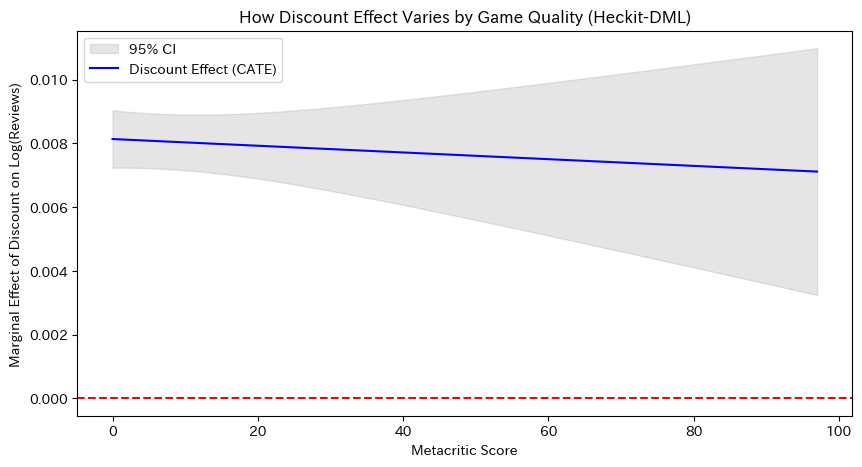

In [6]:
df['num_reviews_total'] = df['num_reviews_total'].replace(-1, 0)
df['is_active'] = (df['num_reviews_total'] > 0).astype(int)
df['is_early_access'] = df['genres'].fillna('').str.contains('Early Access').astype(int)
df['language_count'] = df['supported_languages'].fillna('').apply(lambda x: len(str(x).split(',')))
df['log_reviews'] = np.log1p(df['num_reviews_total'])

genres_dummies = df['genres'].str.get_dummies(sep=',').add_prefix('genre_')
top_20_genres = genres_dummies.sum().sort_values(ascending=False).head(20).index
genres_dummies = genres_dummies[top_20_genres]

Z_cols = ['language_count', 'windows', 'mac', 'linux', 'is_early_access']
for col in Z_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(float)

Z = sm.add_constant(df[Z_cols])
print("Step 1: Running Probit to calculate IMR...")
selection_model = sm.Probit(df['is_active'], Z).fit(disp=0)

prob = selection_model.predict(Z)
z_val = norm.ppf(np.clip(prob, 0.0001, 0.9999))
df['imr'] = norm.pdf(z_val) / norm.cdf(z_val)


df_encoded = pd.concat([df, genres_dummies], axis=1)

W_cols = ['price', 'dlc_count', 'imr'] + list(genres_dummies.columns)
required_cols = ['log_reviews', 'discount', 'metacritic_score'] + W_cols

df_final = df_encoded[df_encoded['is_active'] == 1].dropna(subset=required_cols)

Y = df_final['log_reviews'].values
T = df_final['discount'].values
X = df_final[['metacritic_score']].values
W = df_final[W_cols].values


print(f"Step 2: Running DML on {len(df_final)} samples...")
est = LinearDML(
    model_y=RandomForestRegressor(n_estimators=100, max_depth=5),
    model_t=RandomForestRegressor(n_estimators=100, max_depth=5),
    discrete_treatment=False
)
est.fit(Y, T, X=X, W=W)

test_x_range = np.linspace(df_final['metacritic_score'].min(), df_final['metacritic_score'].max(), 100).reshape(-1, 1)
cate_effects = est.effect(test_x_range)
lb, ub = est.effect_interval(test_x_range, alpha=0.05)

plt.figure(figsize=(10, 5))
plt.fill_between(test_x_range.flatten(), lb, ub, color='gray', alpha=0.2, label='95% CI')
plt.plot(test_x_range, cate_effects, color='blue', label='Discount Effect (CATE)')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Metacritic Score")
plt.ylabel("Marginal Effect of Discount on Log(Reviews)")
plt.title("How Discount Effect Varies by Game Quality (Heckit-DML)")
plt.legend()
plt.show()

In [5]:
# --- 0. 基本的な前処理とフラグ作成 ---
# ターゲットフラグ：レビューが1つ以上あればアクティブ（参入成功）とする
df['is_active'] = (df['num_reviews_total'] > 0).astype(int)

# 補助的な変数作成
df['is_early_access'] = df['genres'].fillna('').str.contains('Early Access').astype(int)
df['language_count'] = df['supported_languages'].fillna('').apply(lambda x: len(str(x).split(',')))

# 対数変換（歪んだ分布を整える）
df['log_ccu'] = np.log1p(df['peak_ccu'])
df['log_num_reviews_total'] = np.log1p(df['num_reviews_total'])

# --- 1. Selection Stage の前処理（型変換） ---

# 使う予定の変数リスト
Z_cols = ['language_count', 'windows', 'mac', 'linux', 'is_early_access', 'dlc_count']

# 【重要】すべての列を強制的に数値（float）に変換し、変換できないものは NaN にする
# その後、欠損値（NaN）があると Probit は動かないので 0 で埋めるか、行を落とす
for col in Z_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(float)

# is_active も念のため強制変換
df['is_active'] = pd.to_numeric(df['is_active'], errors='coerce').fillna(0).astype(int)

# 定数項を加える前に、念のため Z_cols の中身に Object 型が残っていないか確認
print("Data types for Probit:\n", df[Z_cols].dtypes)

# 再度 Z を作成
Z = sm.add_constant(df[Z_cols])

print("Running Probit for Selection Stage...")
# これでエラーが出なくなるはずです
selection_model = sm.Probit(df['is_active'], Z).fit()

# 逆ミルズ比 (IMR) の算出
prob = selection_model.predict(Z)
# 数値計算上のエラーを防ぐために確率を微調整してz値を逆算
z_val = norm.ppf(np.clip(prob, 0.0001, 0.9999))
df['imr'] = norm.pdf(z_val) / norm.cdf(z_val)

# --- 2. 特徴量エンジニアリング（ジャンル・カテゴリの展開） ---
# ジャンルをOne-hot展開し、多すぎると計算が重くなるので上位20個に絞る
genres_dummies = df['genres'].str.get_dummies(sep=',').add_prefix('genre_')
top_20_genres = genres_dummies.sum().sort_values(ascending=False).head(20).index
genres_dummies = genres_dummies[top_20_genres]

# カテゴリも同様に処理（必要なら）
categories_dummies = df['categories'].str.get_dummies(sep=';').add_prefix('cat_')
top_10_cats = categories_dummies.sum().sort_values(ascending=False).head(10).index
categories_dummies = categories_dummies[top_10_cats]

# 全データを結合した df_encoded を作成（ここで初めて imr と dummies が合体する）
df_encoded = pd.concat([df, genres_dummies, categories_dummies], axis=1)

# --- 3. Outcome Stage: DML用のデータ作成 ---
# 分析対象は「市場に参入している（is_active == 1）」個体のみ
df_active = df_encoded[df_encoded['is_active'] == 1].copy()

# 共変量 W (コントロール変数) のリスト作成
# 末石本の教え通り、imr をここに含めることで選択バイアスを制御する
W_cols = ['price', 'dlc_count', 'achievements', 'imr', 'language_count'] + \
         list(genres_dummies.columns) + list(categories_dummies.columns)

# DMLは欠損値を許容しないため、一気に落とす
# Y, T, X, W に使うすべての列を指定
required_cols = ['log_num_reviews_total', 'discount', 'metacritic_score'] + W_cols
df_final = df_active.dropna(subset=required_cols)

# DML用の行列に変換

Y = df_final['log_num_reviews_total'].values
T = df_final['discount'].values
X = df_final[['metacritic_score']].values # メタスコアによる効果の差（CATE）を見たい場合
W = df_final[W_cols].values

print(f"Final Data Shape: {df_final.shape}")
print("Ready for DML estimation.")

# --- 4. (参考) DMLの実行例 ---
# est = LinearDML(model_y=RandomForestRegressor(), model_t=RandomForestRegressor(), discrete_treatment=False)
# est.fit(Y, T, X=X, W=W)

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


Data types for Probit:
 language_count     float64
windows            float64
mac                float64
linux              float64
is_early_access    float64
dlc_count          float64
dtype: object
Running Probit for Selection Stage...
Optimization terminated successfully.
         Current function value: 0.661030
         Iterations 5
Final Data Shape: (53199, 87)
Ready for DML estimation.


In [ ]:
# --- 0. 関数定義：ジャンル・カテゴリの多重展開 ---
def get_top_dummies(df, column, sep=';', top_n=20):
    # 分割してダミー化
    dummies = df[column].fillna('').str.get_dummies(sep=sep)
    # 頻度上位のみ抽出
    top_cols = dummies.sum().sort_values(ascending=False).head(top_n).index
    return dummies[top_cols].add_prefix(f"{column.rstrip('s')}_")

# --- 1. Selection Stage (Heckman第一段階) ---
# 前処理
df['is_early_access'] = df['genres'].fillna('').str.contains('Early Access').astype(int)
df['language_count'] = df['supported_languages'].fillna('').str.split(',').str.len()

# Z（選択式に含まれるが、売上には直接影響しにくい「操作変数」的変数を含む）
Z_cols = ['language_count', 'windows', 'mac', 'linux', 'is_early_access', 'dlc_count']
Z = sm.add_constant(df[Z_cols])

# Probit推定
selection_model = sm.Probit(df['is_active'], Z).fit()

# IMR (逆ミルズ比) の計算
prob = selection_model.predict(Z)
phi = norm.pdf(norm.ppf(np.clip(prob, 0.001, 0.999)))
df['imr'] = phi / np.clip(prob, 0.001, 0.999)

# --- 2. Outcome Stage 用のデータ整理 ---
# ジャンル(20個)とカテゴリ(15個)を展開
genres_dummies = get_top_dummies(df, 'genres', sep=';', top_n=20)
categories_dummies = get_top_dummies(df, 'categories', sep=';', top_n=15)

# 分析対象の絞り込み（アクティブかつ、割引情報があるもの）
df_active = df[df['is_active'] == 1].copy()

# 共変量 W の作成 (IMR + 数値変数 + ジャンル + カテゴリ)
W_numeric_cols = ['price', 'dlc_count', 'imr', 'pct_pos_total']
W_matrix = pd.concat([
    df_active[W_numeric_cols],
    genres_dummies.loc[df_active.index],
    categories_dummies.loc[df_active.index]
], axis=1).fillna(0)

# DMLに渡す変数の確定
Y = np.log1p(df_active['peak_ccu']) # Outcome: 例としてCCUの対数
T = df_active['discount_pct']      # Treatment: 割引率
X = df_active[['metacritic']]      # Heterogeneity: メタスコアによる効果の違いを見る
W = W_matrix.values               # Controls: 「掃除」用変数群

# --- 3. DML の実行 ---
# LassoCV を使うことで、40近い共変量の中から重要なものだけを自動選択させる
from econml.dml import LinearDML

est = LinearDML(
    model_y=LassoCV(cv=3),
    model_t=LassoCV(cv=3),
    discrete_treatment=False
)

print(f"Final W shape: {W.shape} (Variables: {W_matrix.columns.tolist()})")
est.fit(Y, T, X=X, W=W)

In [ ]:
# 1. データの準備（Sand_03 を想定）
# T: 処置（割引率 0-100）
# X: 条件（CATEを見たい変数：メタスコアなど）
# W: 共変量（掃除したい変数：ポジティブ率、価格、タグ、ジャンルなど）
# Y_vol: 量（レビュー数） / Y_qual: 質（中央値プレイ時間）

T = df['discount'].values
X = df[['metacritic_score']].values  # メタスコアによって効果が変わるか見たい
W = df[['pct_pos_total', 'price', 'dlc_count', 'is_early_access']].values # 炎上率等で掃除

# 目的変数は対数変換（0を避けるため +1）
Y_vol = np.log(df['num_reviews_total'] + 1).values
Y_qual = np.log(df['median_playtime_forever'] + 1).values

# 2. モデルの定義（Double Machine Learning）
# 機械学習（Random Forest）で T と Y のノイズを掃除する
def estimate_cate(Y, T, X, W):
    est = LinearDML(
        model_y=RandomForestRegressor(n_estimators=100, max_depth=5, min_samples_leaf=10),
        model_t=RandomForestRegressor(n_estimators=100, max_depth=5, min_samples_leaf=10),
        discrete_treatment=False
    )
    est.fit(Y, T, X=X, W=W)
    return est

# 3. 「量」と「質」のそれぞれで CATE を推定
print("Estimating Volume Effect (Reviews)...")
est_vol = estimate_cate(Y_vol, T, X, W)

print("Estimating Quality Effect (Playtime)...")
est_qual = estimate_cate(Y_qual, T, X, W)

# 4. 可視化：メタスコアが上がると、割引の「量」と「質」への効果はどう変わるか
test_X = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
cate_vol = est_vol.effect(test_X)
cate_qual = est_qual.effect(test_X)

plt.figure(figsize=(10, 6))
plt.plot(test_X, cate_vol, label='CATE: Volume (Reviews)', color='blue')
plt.plot(test_X, cate_qual, label='CATE: Quality (Playtime)', color='green')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Metacritic Score')
plt.ylabel('Marginal Treatment Effect of Discount')
plt.title('Quantity vs. Quality Trade-off in Discounting')
plt.legend()
plt.show()

KeyError: "['is_early_access'] not in index"

でもこれ同時方程式じゃ。IVーDML使った方がいいんじゃないか。

いや売れてるゲームほど割引するって仮説は繊細すぎるか、一旦この2変数とdiscountの相関見るか。だって売れてないゲームも割引するだろうから打ち消されそうだ

でもそもそもマジで一応市場に出ただけみたいなクソゲーもdiscountしないだろうしやっぱりreviewをheckmanで切りたくなってしまうな。難しい

Low-end (クソゲー): そもそも割引すら設定されず放置される。

Mid-range (普通): 売れないから割引する（負の相関）。

High-end (人気作): セールイベントで戦略的に割引し、さらに売れる（正の相関）。

これらがデータセット内で混ざると、全体の係数は「0」に近づき、「割引は意味がない」という誤った結論を導きます。

4. 暫定的な解決策：Heckman-DML 的なアプローチ

最新の論文でも議論される内容ですが、現実的な解として以下を提案します。

Step 1: フィルタリング（Heckman の精神）
「レビューが 10 以上」などの最低限の足切りを行い、さらに「過去に一度でも割引をしたことがあるか」というプロビットを回して IMR（逆ミルズ比） を出す。

Step 2: DML への投入
その IMR をコントロール変数として DML にぶち込みます。これで「割引戦略をとるようなゲーム層」における、純粋な割引効果を推定できます。

In [ ]:
# 1. Selection Stage: 逆ミルズ比 (IMR) の算出
# 全データを使用して「一定以上のレビューがあるか」という生存フラグを作成
df['is_observed'] = (df['num_reviews_total'] > 10).astype(int)

# 選択方程式の変数 Z (排外制約: 生存には効くが、売上そのものには直接関わらないもの)
# 例: 発売からの日数、言語数、特定のカテゴリフラグなど
Z_cols = ['language_count', 'is_early_access', 'windows', 'mac', 'linux']
Z = sm.add_constant(df[Z_cols])

# プロビット回帰の実行
probit_model = sm.Probit(df['is_observed'], Z).fit()

# 各サンプルに対して逆ミルズ比 (IMR) を計算
# phi(z)/Phi(z)
z_score = probit_model.predict(Z)
# predictは確率を出すので、逆関数で標準正規分布のzスコアに戻す必要がある
z_val = norm.ppf(np.clip(z_score, 0.001, 0.999))
df['imr'] = norm.pdf(z_val) / norm.cdf(z_val)

# 2. DML Stage: 選択バイアスを補正した CATE 推定
# 分析対象を「観測されたデータ」に絞る
df_sub = df[df['is_observed'] == 1].copy().dropna(subset=['metacritic_score', 'discount'])

# Y: 目的変数 (量: reviews / 質: playtime)
Y = np.log(df_sub['num_reviews_total'] + 1).values

# T: 処置変数 (割引率)
T = df_sub['discount'].values

# X: 条件変数 (CATEを見たい軸)
X = df_sub[['metacritic_score']].values

# W: 共変量 (IMRをここに追加するのがキモ)
# 他にコントロールしたい変数（炎上率など）も入れる
W = df_sub[['pct_pos_total', 'price', 'imr']].values

# LinearDML の定義
est = LinearDML(
    model_y=RandomForestRegressor(n_estimators=100, max_depth=5),
    model_t=RandomForestRegressor(n_estimators=100, max_depth=5),
    discrete_treatment=False
)

# 学習
print("Fitting Heckman-DML model...")
est.fit(Y, T, X=X, W=W)

# 3. 結果の解釈
# メタスコアごとの割引の限界効果を表示
test_X = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
treatment_effects = est.effect(test_X)

import matplotlib.pyplot as plt
plt.plot(test_X, treatment_effects)
plt.axhline(0, color='r', linestyle='--')
plt.title("CATE of Discount (Heckman-DML Corrected)")
plt.xlabel("Metacritic Score")
plt.ylabel("Treatment Effect on Log Reviews")
plt.show()

でもこれヘックマンの必然性あるのか？対数変換しても尖度がこの程度あるから切った。みたいなのって妥当性あるのか？Truncated Regressionの方がいいか？でも、そもそも売れてなくて、戦略としてすら割引をしないゲームを第一段階で省いて、戦略として割引をすることが意味を持ちうるライン（reviewが正）で分けて分析するっていうのは十分な根拠か


In [ ]:
# 1. Selection Stage (Heckman): 戦略的参入のモデリング
# 「レビューが1つ以上あるか」を市場参入の証拠とする
df['is_active'] = (df['num_reviews_total'] > 0).astype(int)

# 選択方程式の共変量 Z (排外制約: 露出やプラットフォーム対応など)
Z_cols = ['language_count', 'windows', 'mac', 'linux', 'is_early_access']
Z = sm.add_constant(df[Z_cols])

# プロビットモデルで「参入確率」を推定
selection_model = sm.Probit(df['is_active'], Z).fit()

# 逆ミルズ比 (IMR) の算出
# 確率 P から標準正規分布の z 値を逆算し、IMRを導出
prob = selection_model.predict(Z)
z_val = norm.ppf(np.clip(prob, 0.0001, 0.9999))
df['imr'] = norm.pdf(z_val) / norm.cdf(z_val)

# 2. Outcome Stage (DML): 参入個体における割引の CATE 推定
# 「市場に参入している」個体のみを抽出
df_active = df[df['is_active'] == 1].copy().dropna(subset=['metacritic_score', 'discount'])

# Y: 目的変数 (量: reviews / 質: playtime)
# 対数変換で分布を整えつつ、IMRで選択バイアスを制御する
Y = np.log(df_active['num_reviews_total'] + 1).values
T = df_active['discount'].values
X = df_active[['metacritic_score']].values  # メタスコアで効果の差（CATE）を見る
W = df_active_W_matrix.values

# DML モデルの定義
est = LinearDML(
    model_y=RandomForestRegressor(n_estimators=100, max_depth=5, min_samples_leaf=10),
    model_t=RandomForestRegressor(n_estimators=100, max_depth=5, min_samples_leaf=10),
    discrete_treatment=False
)

print("Running Heckman-DML for CATE estimation...")
est.fit(Y, T, X=X, W=W)

# 3. 可視化：メタスコアによる割引効果の変遷
test_X = np.sort(X, axis=0)
cate_effects = est.effect(test_X)
lb, ub = est.effect_interval(test_X, alpha=0.05) # 95%信頼区間

plt.figure(figsize=(10, 6))
plt.fill_between(test_X.flatten(), lb, ub, color='gray', alpha=0.2, label='95% CI')
plt.plot(test_X, cate_effects, label='Marginal Effect of Discount', color='blue', lw=2)
plt.axhline(0, color='red', linestyle='--')
plt.title("Heterogeneous Treatment Effect of Discounting\n(Controlled for Selection Bias via IMR)")
plt.xlabel("Metacritic Score")
plt.ylabel("Effect on Log(Total Reviews)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()